# Day 23 - GPT - 自回归语言模型

> GPT: 从左到右预测下一个词 = 自回归 (Autoregressive)
>
> BERT 做填空 (双向), GPT 做续写 (单向)

---

## BERT vs GPT

```
            BERT                              GPT
      ┌──────────────────┐           ┌──────────────────┐
训练:   MLM 遮词猜词              下一个词预测
方向:   双向 (看全部)              单向 (只看左边)
架构:   Transformer Encoder       Transformer Decoder
注意力:  Self-Attention (全连)     Masked Self-Attention (下三角)
适合:   理解 (分类/标注/QA)        生成 (写文章/代码/对话)
典型:   BERT, RoBERTa             GPT-2, GPT-3, GPT-4
```

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
os.environ['HF_ENDPOINT'] = 'https://hf-mirror.com'
os.environ['HF_HOME'] = 'D:\\hyy\\vscode\\vscode模型'

import torch
import numpy as np
import matplotlib.pyplot as plt

print('=' * 40)
print('Day 23 - GPT')
print('=' * 40)

Day 23 - GPT


## 1. 加载 GPT-2

> 用 HuggingFace 的 GPT-2 (124M 参数), 看看它怎么续写文本

In [2]:
from transformers import AutoTokenizer, AutoModelForCausalLM

model_name = 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 没有 pad_token, 用 eos 代替
model = AutoModelForCausalLM.from_pretrained(model_name)

print(f'GPT-2 参数量: {sum(p.numel() for p in model.parameters()):,}')
print(f'词表大小: {tokenizer.vocab_size}')
print(f'最大长度: {model.config.max_position_embeddings}')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT-2 参数量: 124,439,808
词表大小: 50257
最大长度: 1024


## 2. 文本生成 — 下一个词预测

> GPT 的核心: 给定前面的词, 预测下一个最可能的词
>
> 把预测出的词拼回去 → 再预测下一个 → 循环 = 生成

### 生成策略对比

| 策略 | 特点 | 效果 |
|:----|:-----|:-----|
| **greedy** | 每次取概率最高的词 | 重复、单调 |
| **sampling** | 按概率分布随机采样 | 多样但有语法错误 |
| **top-k** | 只从前 k 个里采样 | 平衡多样性 + 质量 |
| **top-p (nucleus)** | 从累计概率 p 的集合里采样 | 最常用, 质量最高 |

In [8]:
# ============================================
# 四种生成策略对比
# ============================================

def generate_text(prompt, strategy='greedy', **kwargs):
    """用不同策略生成文本"""
    # 将输入的提示词（prompt）转换为模型可识别的张量（Token IDs）
    inputs = tokenizer(prompt, return_tensors='pt')

    # 定义不同的文本生成策略及其对应的参数配置
    strategies = {
        # 贪婪搜索：每次都选择概率最高的Token，结果完全确定
        'greedy':   {'do_sample': False, 'num_beams': 1},
        # 随机采样：开启采样，温度设为1.0（保持原始概率分布），top_k为0表示不限制候选词数量
        'sampling': {'do_sample': True, 'temperature': 1.0, 'top_k': 0},
        # Top-k 采样：只从概率最高的前50个词中随机采样，温度0.8稍微降低随机性
        'top_k':    {'do_sample': True, 'top_k': 50, 'temperature': 0.8},
        # Top-p 采样（核采样）：从累积概率达到90%的最小词集中随机采样，温度0.7
        'top_p':    {'do_sample': True, 'top_p': 0.9, 'temperature': 0.7},
    }
    # 获取指定策略的参数，若策略名不存在则默认使用贪婪搜索
    params = strategies.get(strategy, strategies['greedy'])
    # 允许调用者通过 kwargs 覆盖或添加额外的生成参数
    params.update(kwargs)

    # 禁用梯度计算，仅进行推理以节省显存和计算资源
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_new_tokens=100,          # 限制最多生成100个新Token
            pad_token_id=tokenizer.eos_token_id, # 设置填充Token ID，避免警告
            **params                    # 解包并传入具体的生成策略参数
        )
    # 将模型输出的Token IDs解码回人类可读的文本，并跳过特殊标记（如[EOS]、[PAD]）
    return tokenizer.decode(out[0], skip_special_tokens=True)

prompt = 'Artificial intelligence will'
print(f'提示词: "{prompt}"')
print('=' * 50)

# 依次使用贪婪搜索、Top-k 和 Top-p 三种策略生成文本并打印结果
for name in ['greedy', 'top_k', 'top_p']:
    result = generate_text(prompt, name)
    print(f'\n[{name}]')
    print(f'  {result}')

提示词: "Artificial intelligence will"

[greedy]
  Artificial intelligence will be able to do things like search for and find people, and to do things like find out who's in the right place at the right time.

"We're going to be able to do things like that, and we're going to be able to do things like that, and we're going to be able to do things like that, and we're going to be able to do things like that, and we're going to be able to do things like that, and we're

[top_k]
  Artificial intelligence will not replace human intelligence, but will create new kinds of information which will allow us to better understand more of what we are talking about.

For example, we can be good at understanding things we don't know. And we can help out those people who are not already doing it.

So far, it is only possible to understand what is happening in a world that is changing over millions of years.

But I want to talk about something that is perhaps my favorite aspect of the

[top_p]
  Artificia

## 3. 对比 BERT 和 GPT 的注意力掩码

> BERT: 全连接 (双向), GPT: 下三角 (单向)
>
> 这个掩码是它们最本质的区别

[transformers] The following generation flags are not valid and may be ignored: ['output_attentions']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

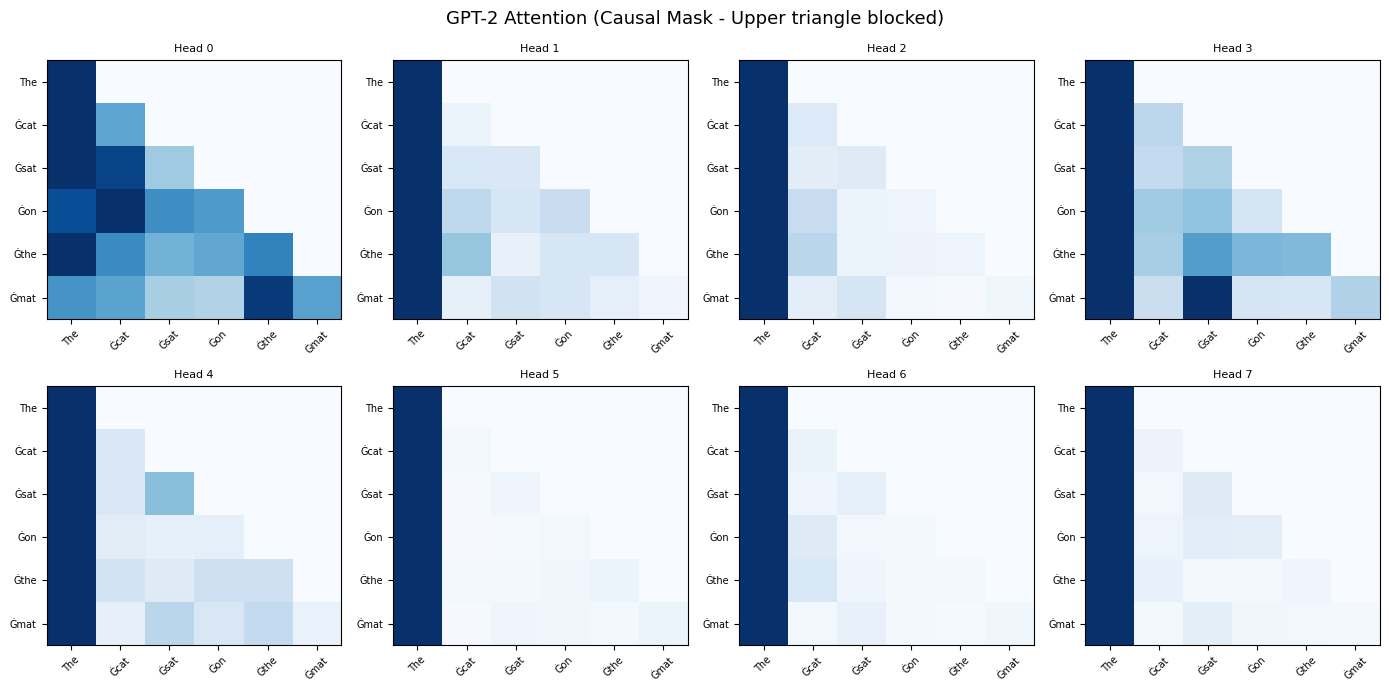

关键观察:
  右上角是黑的 = 被 mask 挡住了 (看不到右边)
  每个位置只能看自己和左边的词
  这是 GPT 跟 BERT 最本质的区别


In [9]:
# ============================================
# 可视化 GPT 的 causal mask
# ============================================

from transformers import AutoModelForCausalLM

# 加载 GPT-2 并提取 attention
gpt2 = AutoModelForCausalLM.from_pretrained('gpt2', output_attentions=True)

text = 'The cat sat on the mat'
inputs = tokenizer(text, return_tensors='pt')

with torch.no_grad():
    out = gpt2(**inputs, output_attentions=True)

# GPT-2 有 12 层, 取最后一层
attn = out.attentions[-1][0]  # (heads, seq, seq)
words = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for i, ax in enumerate(axes.flatten()):
    m = attn[i, :len(words), :len(words)].numpy()
    ax.imshow(m, cmap='Blues', aspect='auto', vmin=0, vmax=0.3)
    ax.set_xticks(range(len(words))); ax.set_yticks(range(len(words)))
    ax.set_xticklabels(words, fontsize=7, rotation=45)
    ax.set_yticklabels(words, fontsize=7)
    ax.set_title(f'Head {i}', fontsize=8)
plt.suptitle('GPT-2 Attention (Causal Mask - Upper triangle blocked)', fontsize=13)
plt.tight_layout()
plt.savefig('day23_gpt_attention.png', dpi=120)
plt.show()

print('关键观察:')
print('  右上角是黑的 = 被 mask 挡住了 (看不到右边)')
print('  每个位置只能看自己和左边的词')
print('  这是 GPT 跟 BERT 最本质的区别')

## 4. Prompt Engineering 演示

> 同一个问题, 不同 prompt 得到的答案质量完全不同

In [11]:
def ask_gpt2(prompt, max_new=90):
    inputs = tokenizer(prompt, return_tensors='pt')
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new,
            do_sample=True, top_p=0.9, temperature=0.7,
            pad_token_id=tokenizer.eos_token_id
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)

print('Prompt 对比:')
print()
print('--- 差的 prompt ---')
r1 = ask_gpt2('Tell me about machine learning.')
print(f'  {r1}')
print()
print('--- 好的 prompt ---')
r2 = ask_gpt2('Machine learning is a field of artificial intelligence that')
print(f'  {r2}')
print()
print('--- 带格式的 prompt ---')
r3 = ask_gpt2('Q: What is machine learning?\nA:')
print(f'  {r3}')

Prompt 对比:

--- 差的 prompt ---
  Tell me about machine learning.

Machine learning is a new field of research that has been around for a very long time. It's a new field of research that has been around for a very long time, but it's been around for a very long time, and now it's time to start learning.

And I think that machine learning is a great start, because it's a new field of research that has been around for a very long time. And that

--- 好的 prompt ---
  Machine learning is a field of artificial intelligence that can be applied to many different industries.

We are interested in exploring the potential of machine learning to help businesses and organizations create better products, services, and processes.

This article will focus on the research and development of machine learning to help businesses and organizations create better products, services, and processes.

Machine learning is a field of artificial intelligence that can be applied to many different industries.

Machin

## 5. GPT 演化史

> GPT 系列的核心: 规模扩大 → 能力涌现

```
GPT-1 (2018):   117M 参数  → "预训练 + 微调" 范式
  12层 Transformer Decoder
  证明: 无监督预训练有用

GPT-2 (2019):   1.5B 参数  → "zero-shot" 能力
  48层, 主要改进数据质量和规模
  发现: 模型变大后, 不用微调也能做任务
  "不开源完整模型" 事件

GPT-3 (2020):   175B 参数  → "in-context learning"
  96层, 训练成本 460 万美元
  发现: 给几个例子就能学 (few-shot)
  prompt engineering 诞生

GPT-4 (2023):   多模态?  → "多模态 + 推理"
  具体参数未公开
  能看图, 能通过多种考试

关键洞察:
  模型足够大 → 涌现能力 (emergent abilities)
  小模型做不到的事, 大模型突然就会了
  这就是为什么 GPT-3 比 GPT-2 大 100 倍
```

---

# Day 23 完成!

## 总结

| 概念 | 一句话 |
|------|--------|
| **自回归** | 根据历史预测下一个词, 把预测拼回去继续预测 |
| **Causal Mask** | 下三角矩阵, 每个位置只看左边 |
| **生成策略** | greedy / sampling / top-k / top-p |
| **GPT 演化** | GPT-1(117M) → GPT-2(1.5B) → GPT-3(175B) → GPT-4 |
| **涌现能力** | 模型足够大时突然出现的技能 |

## BERT vs GPT 本质区别

```
BERT: 双向 Encoder → 适合理解
GPT:  单向 Decoder → 适合生成

但最新的趋势:
  T5: Encoder + Decoder (用填空做所有任务)
  BART: Encoder + Decoder (去噪自编码)
  GPT 系列: 只用 Decoder, 越来越大
```

## 作业 (2 题)

### 1. 调整生成策略
**位置:** cell-5, `generate_text()` 调用

试试把 `temperature` 改成 0.2 (更保守) 和 1.5 (更随机), 观察输出差异

<details>
<summary>📖 答案</summary>
temperature=0.2: 输出非常保守, 几乎总是选最高概率词, 可能重复
temperature=1.5: 输出更随机, 可能有语法错误但更有创意
top_p=0.9 是最常用的平衡方案
</details>

### 2. GPT vs BERT 注意力
**位置:** cell-7, GPT 注意力图

对比 Day22 cell-5 的 BERT 注意力图, 最明显的区别是什么?

<details>
<summary>📖 答案</summary>
GPT: 右上角全黑 (causal mask 挡住右边)
BERT: 全彩色 (每个位置看所有位置)
这导致:
  训练方式不同 (MLM vs 下一个词预测)
  应用不同 (理解 vs 生成)
</details>